# 5. ExceedGAN for bivariate extremes

This notebook introduces **Fixed-Level ExceedGAN (FL-ExceedGAN)** and compares it with a standard GAN and EV-GAN.

We use the simulation setting from the supplied slides:

$$
d=2,\qquad \mu=2,\qquad \gamma=0.5,\qquad
(\rho_1,\rho_2)=(-1,-3),
$$

with a Gumbel copula, Burr margins and

$$
\boldsymbol\delta_n=(0.1,0.1)^\top.
$$

The target is the upper-orthant exceedance distribution

$$
Y(\boldsymbol\delta_n)
\overset{d}{=}
X\mid
X^{(1)}>u_n^{(1)},\;
X^{(2)}>u_n^{(2)},
$$

where

$$
u_n^{(m)}=F_{X^{(m)}}^{-1}(1-\delta_n^{(m)}).
$$

We implement the **fixed-level** version because it is the direct comparison to GAN and EV-GAN at one specified threshold.

## Learning objectives

By the end you should be able to:

1. construct $\mathcal Q(\boldsymbol\delta_n)$;
2. explain why exceedance generation is an extrapolation problem;
3. describe the log-spacing function;
4. explain the role of eLU activations;
5. construct GAN, EV-GAN, and FL-ExceedGAN generators in PyTorch;
6. compare their marginal tail fit and bivariate dependence.

## Packages

If necessary:

```python
 pip install torch numpy pandas matplotlib scipy statsmodels
```

In [3]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from scipy import stats as st
from scipy.special import expi
from scipy.stats import kendalltau
from statsmodels.distributions.copula.api import CopulaDistribution, GumbelCopula

SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("PyTorch:", torch.__version__)
print("Device:", device)

PyTorch: 2.2.1
Device: mps


# 1. Simulate Gumbel-copula data with Burr margins

For margin $m$, use a Burr XII distribution with

$$
c_m=-\frac{\rho_m}{\gamma},
\qquad
d_m=-\frac{1}{\rho_m}.
$$

The Gumbel copula parameter is $\mu=2$.

In [4]:
N_TRAIN = 25_000
N_TEST = 100_000

MU = 2.0
GAMMA = 0.5
RHOS = (-1.0, -3.0)
DELTA = np.array([0.10, 0.10], dtype=np.float32)

def generate_gumbel_burr(n, mu=MU, gamma=GAMMA, rhos=RHOS, seed=123):
    marginals = [
        st.burr12(c=-rho/gamma, d=-1.0/rho)
        for rho in rhos
    ]
    distribution = CopulaDistribution(
        copula=GumbelCopula(theta=mu, k_dim=2),
        marginals=marginals
    )
    return np.asarray(
        distribution.rvs(n, random_state=seed),
        dtype=np.float32
    )

X_train_full = generate_gumbel_burr(N_TRAIN, seed=SEED)
X_test_full = generate_gumbel_burr(N_TEST, seed=SEED + 1)

print("Training:", X_train_full.shape)
print("Test:", X_test_full.shape)

Training: (25000, 2)
Test: (100000, 2)


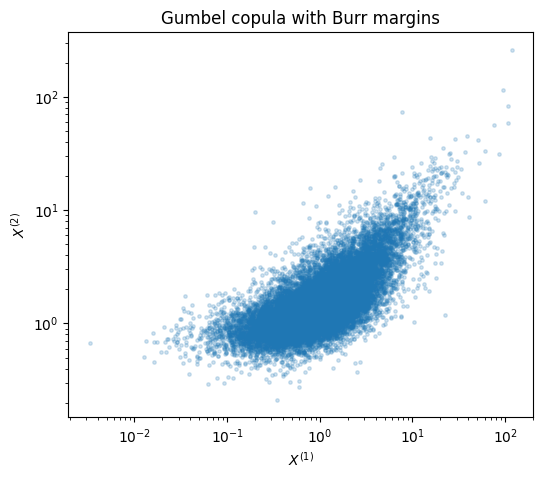

In [5]:
plt.figure(figsize=(6,5))
plt.scatter(X_train_full[:,0], X_train_full[:,1], s=6, alpha=0.2)
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$X^{(1)}$")
plt.ylabel(r"$X^{(2)}$")
plt.title("Gumbel copula with Burr margins")
plt.show()

# 2. The upper-quadrant region

The slides define

$$
\mathcal Q(\boldsymbol\delta_n)
=
\left\{
x\in\mathbb R^2:
x^{(m)}>F_{X^{(m)}}^{-1}(1-\delta_n^{(m)}),
\;m=1,2
\right\}.
$$

We estimate the anchor points from the training sample and use those same anchors for the independent test set.

In [6]:
def get_upper_quadrant(X, delta, anchor_points=None):
    X = np.asarray(X)
    delta = np.asarray(delta)

    if anchor_points is None:
        anchor_points = np.array([
            np.quantile(X[:, m], 1.0-delta[m])
            for m in range(X.shape[1])
        ])

    anchor_points = np.asarray(anchor_points, dtype=np.float32)

    mask = np.all(
        X > anchor_points.reshape(1, -1),
        axis=1
    )

    return X[mask], anchor_points

X_train, anchor_points = get_upper_quadrant(X_train_full, DELTA)
X_test, _ = get_upper_quadrant(
    X_test_full,
    DELTA,
    anchor_points=anchor_points
)

print("Anchor points:", anchor_points)
print("Training exceedances:", len(X_train))
print("Test exceedances:", len(X_test))

Anchor points: [2.9915762 3.149323 ]
Training exceedances: 1529
Test exceedances: 6144


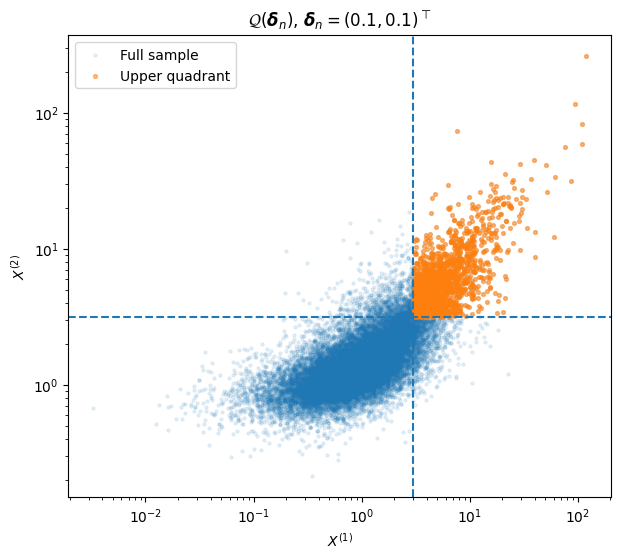

In [8]:
plt.figure(figsize=(7,6))
plt.scatter(X_train_full[:,0], X_train_full[:,1], s=5, alpha=0.10, label="Full sample")
plt.scatter(X_train[:,0], X_train[:,1], s=8, alpha=0.5, label="Upper quadrant")
plt.axvline(anchor_points[0], linestyle="--")
plt.axhline(anchor_points[1], linestyle="--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r"$X^{(1)}$")
plt.ylabel(r"$X^{(2)}$")
plt.title(
    r"$\mathcal{Q}(\boldsymbol{\delta}_n)$, "
    r"$\boldsymbol{\delta}_n=(0.1,0.1)^\top$"
)
plt.legend()
plt.show()

# 3. ExceedGAN is an extrapolation model

For one margin,

$$
Y=X\mid X>q_X(1-\delta).
$$

If $Z\sim U(0,1)$, then

$$
q_Y(1-z)=q_X(1-\delta z).
$$

When $n\delta z$ is small, $q_X(1-\delta z)$ may be beyond the observed range. Estimating the exceedance generator is therefore an **extrapolation problem**.

# 4. The log-spacing function

Write

$$
U(t)=q_X(1-1/t)=t^\gamma L(t),
$$

where $L$ is slowly varying. Then

$$
q_Y(1-z)=U\left(\frac{1}{\delta z}\right),
$$

and

$$
\log U\left(\frac{1}{\delta z}\right)
-
\log U\left(\frac{1}{\delta}\right)
=
\gamma\log(1/z)
+
\varphi\left(\log(1/z),\log(1/\delta)\right).
$$

Hence

$$
q_Y(1-z)
=
q_X(1-\delta)\,
z^{-\gamma}
\exp\left[
\varphi\left(\log(1/z),\log(1/\delta)\right)
\right].
$$

# 5. Why eLU?

The second-order approximation in the slides uses

$$
\sigma^E(x)
=
\begin{cases}
x,&x\ge 0,\\
e^x-1,&x<0,
\end{cases}
$$

which is PyTorch's `nn.ELU(alpha=1)`.

The public fixed-level implementation can be written schematically as

$$
G_\theta^{\mathrm{EX}}(Z)
=
\widehat u_n
\odot
\exp\left[
\sigma^R
\left\{
N_\theta(-\log Z,-\log\boldsymbol\delta_n)
\right\}
\right].
$$

The empirical threshold is therefore built directly into the generator.

# 6. Construct the three generators

We use

$$
d'=10,\qquad J_G=30,
$$

matching the public example's basic network sizes.

In [9]:
DIM_DATA = 2
LATENT_DIM = 10
HIDDEN_G = 30
HIDDEN_D = (10, 10)

def sample_Z(n):
    return torch.rand(n, LATENT_DIM, device=device).clamp(1e-5, 1-1e-5)

## 6.1 Standard GAN

In [10]:
class StandardGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(LATENT_DIM, HIDDEN_G),
            nn.ReLU(),
            nn.Linear(HIDDEN_G, DIM_DATA)
        )

    def forward(self, z):
        return F.relu(self.layers(z))

## 6.2 EV-GAN

EV-GAN uses

$$
H_u^{-1}(x)
=
\left(\frac{1-u^2}{2}\right)^{-x}
$$

after adding the corrected-TIF terms. The first two latent coordinates supply the two marginal TIF transforms.

In [11]:
class TIFInverse(nn.Module):
    def forward(self, u, x):
        u = u.clamp(1e-5, 1-1e-5)
        base = ((1-u.pow(2))/2.0).clamp_min(1e-8)
        return torch.exp((-x*torch.log(base)).clamp(max=20.0))

class EVGenerator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(LATENT_DIM, HIDDEN_G),
            nn.ReLU(),
            nn.Linear(HIDDEN_G, DIM_DATA)
        )
        self.tif_inverse = TIFInverse()

        self.var1 = nn.Parameter(torch.full((1,DIM_DATA), 0.25))
        self.var2 = nn.Parameter(torch.zeros(1,DIM_DATA))
        self.var3 = nn.Parameter(torch.zeros(1,DIM_DATA))
        self.var4 = nn.Parameter(torch.zeros(1,DIM_DATA))
        self.var5 = nn.Parameter(torch.zeros(1,DIM_DATA))
        self.var6 = nn.Parameter(torch.zeros(1,DIM_DATA))

        nn.init.normal_(self.layers[-1].weight, mean=0.0, std=0.01)
        nn.init.constant_(self.layers[-1].bias, 0.15)

    @staticmethod
    def p01(u):
        return -4*u**5 + 5*u**4

    @staticmethod
    def p00(u):
        return u**3 - 2*u**2 + u

    @staticmethod
    def li(x):
        values = expi(torch.log(x).detach().cpu().numpy())
        return torch.as_tensor(values, dtype=x.dtype, device=x.device)

    def Phi(self, u):
        v = (1-u).clamp_min(1e-6)
        logv = torch.log(v)
        liv = self.li(v)
        return (
            self.var2/logv
            + self.var3*liv
            + self.var4*(v/logv-liv)
            + self.var5*(v*(logv+1)/(2*logv**2)-liv/2)
        )

    def forward(self, z):
        u = z[:,:DIM_DATA]
        network = self.layers(z)
        corr1 = self.p01(u)*(self.var1+self.Phi(u))
        corr1 = torch.nan_to_num(corr1, nan=0.0, posinf=0.0, neginf=0.0)
        corr2 = self.var6*self.p00(u)
        f_tif = F.relu(network+corr1+corr2)
        return self.tif_inverse(u, f_tif)

## 6.3 Fixed-Level ExceedGAN

The fixed-level generator conditions on $-\log \boldsymbol\delta_n$, uses eLU hidden units, and multiplies the final extrapolation factor by the empirical anchor point.

In [12]:
class ExceedGenerator(nn.Module):
    def __init__(self, anchor_levels, anchor_points):
        super().__init__()
        self.register_buffer(
            "anchor_levels",
            torch.tensor(anchor_levels, dtype=torch.float32).reshape(1,-1)
        )
        self.register_buffer(
            "anchor_points",
            torch.tensor(anchor_points, dtype=torch.float32).reshape(1,-1)
        )
        self.layers = nn.Sequential(
            nn.Linear(LATENT_DIM + DIM_DATA, HIDDEN_G),
            nn.ELU(alpha=1.0),
            nn.Linear(HIDDEN_G, DIM_DATA)
        )
        nn.init.normal_(self.layers[-1].weight, mean=0.0, std=0.01)
        nn.init.constant_(self.layers[-1].bias, 0.05)

    def forward(self, z):
        delta_batch = self.anchor_levels.expand(z.shape[0], -1)
        transformed = -torch.log(
            torch.cat([z, delta_batch], dim=1).clamp_min(1e-6)
        )
        network = self.layers(transformed)
        return self.anchor_points * torch.exp(
            F.relu(network).clamp(max=12.0)
        )

# 7. Common discriminator and adversarial loss

For clarity, all three models use the same scalar discriminator

$$
D_\phi:\mathbb R^2\rightarrow\mathbb R.
$$

We use `BCEWithLogitsLoss` and the non-saturating generator loss. Thus the comparison changes the **generator parametrisation**, while keeping the adversarial training principle fixed.

In [13]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(DIM_DATA, HIDDEN_D[0]),
            nn.ReLU(),
            nn.Linear(HIDDEN_D[0], HIDDEN_D[1]),
            nn.ReLU(),
            nn.Linear(HIDDEN_D[1], 1)
        )

    def forward(self, x):
        return self.layers(x).squeeze(-1)

# 8. Train all three models on the same exceedance sample

The real observations supplied to every discriminator are the same points in

$$
\mathcal Q(\boldsymbol\delta_n).
$$

For a live workshop, `EPOCHS = 120` is a reasonable starting point. Increase it if you want a closer numerical reproduction of the paper's simulation study.

In [14]:
BATCH_SIZE = 64
EPOCHS = 120
LR_G = 1e-4
LR_D = 1e-4

def train_model(generator, X_real, epochs=EPOCHS, batch_size=BATCH_SIZE,
                lr_G=LR_G, lr_D=LR_D, seed=SEED):

    torch.manual_seed(seed)
    generator = generator.to(device)
    discriminator = Discriminator().to(device)

    opt_G = torch.optim.Adam(generator.parameters(), lr=lr_G)
    opt_D = torch.optim.Adam(discriminator.parameters(), lr=lr_D)
    criterion = nn.BCEWithLogitsLoss()

    loader = DataLoader(
        TensorDataset(torch.tensor(X_real, dtype=torch.float32)),
        batch_size=batch_size,
        shuffle=True,
        drop_last=True
    )

    history_G, history_D = [], []

    for epoch in range(epochs):
        g_epoch, d_epoch = [], []

        for (x_real,) in loader:
            x_real = x_real.to(device)
            n_batch = x_real.shape[0]

            # Discriminator update
            z = sample_Z(n_batch)
            with torch.no_grad():
                x_fake = generator(z)

            real_logits = discriminator(x_real)
            fake_logits = discriminator(x_fake)

            loss_D = (
                criterion(real_logits, torch.ones_like(real_logits))
                + criterion(fake_logits, torch.zeros_like(fake_logits))
            )

            opt_D.zero_grad()
            loss_D.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 10.0)
            opt_D.step()

            # Generator update
            z = sample_Z(n_batch)
            x_fake = generator(z)
            fake_logits = discriminator(x_fake)

            loss_G = criterion(fake_logits, torch.ones_like(fake_logits))

            opt_G.zero_grad()
            loss_G.backward()
            torch.nn.utils.clip_grad_norm_(generator.parameters(), 10.0)
            opt_G.step()

            d_epoch.append(loss_D.item())
            g_epoch.append(loss_G.item())

        history_D.append(np.mean(d_epoch))
        history_G.append(np.mean(g_epoch))

        if (epoch + 1) % 30 == 0:
            print(
                f"Epoch {epoch+1:3d}/{epochs} | "
                f"D={history_D[-1]:.3f} | G={history_G[-1]:.3f}"
            )

    return generator, discriminator, history_G, history_D

## 8.1 Standard GAN

In [15]:
torch.manual_seed(SEED)
G_gan = StandardGenerator()

G_gan, D_gan, hist_G_gan, hist_D_gan = train_model(
    G_gan, X_train, seed=SEED
)

Epoch  30/120 | D=1.323 | G=0.822


KeyboardInterrupt: 

## 8.2 EV-GAN

In [ ]:
torch.manual_seed(SEED)
G_ev = EVGenerator()

G_ev, D_ev, hist_G_ev, hist_D_ev = train_model(
    G_ev, X_train, seed=SEED
)

## 8.3 Fixed-Level ExceedGAN

In [ ]:
torch.manual_seed(SEED)
G_ex = ExceedGenerator(DELTA, anchor_points)

G_ex, D_ex, hist_G_ex, hist_D_ex = train_model(
    G_ex, X_train, seed=SEED
)

# 9. Training losses

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

axes[0].plot(hist_D_gan, label="GAN")
axes[0].plot(hist_D_ev, label="EV-GAN")
axes[0].plot(hist_D_ex, label="FL-ExceedGAN")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Discriminator loss")
axes[0].legend()

axes[1].plot(hist_G_gan, label="GAN")
axes[1].plot(hist_G_ev, label="EV-GAN")
axes[1].plot(hist_G_ex, label="FL-ExceedGAN")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Generator loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# 10. Simulate upper-quadrant observations

For the standard GAN and EV-GAN we use **acceptance-rejection**: generate candidates and retain those above both anchor points.

FL-ExceedGAN generates above the anchor by construction, so no rejection step is needed.

In [ ]:
@torch.no_grad()
def simulate_upper_quadrant(generator, n, anchor_points,
                            by_construction=False,
                            batch_size=4096,
                            max_draws=1_000_000):
    generator.eval()

    # FL-ExceedGAN is anchored above the threshold by construction.
    if by_construction:
        return generator(sample_Z(n)).cpu().numpy(), 1.0

    anchors = torch.tensor(
        anchor_points,
        dtype=torch.float32
    ).reshape(1, -1)

    accepted = []
    n_accepted = 0
    n_drawn = 0

    while n_accepted < n:
        if n_drawn >= max_draws:
            raise RuntimeError(
                "Maximum proposal count reached. "
                "Try more training epochs."
            )

        m = min(batch_size, max_draws - n_drawn)
        candidate = generator(sample_Z(m)).cpu()
        n_drawn += m

        keep = torch.all(candidate > anchors, dim=1)

        if keep.any():
            new = candidate[keep]
            accepted.append(new)
            n_accepted += new.shape[0]

    out = torch.cat(accepted, dim=0)[:n]
    return out.numpy(), n / n_drawn


N_COMPARE = min(10_000, len(X_test))
X_ref = X_test[:N_COMPARE]

X_gan, rate_gan = simulate_upper_quadrant(
    G_gan, N_COMPARE, anchor_points, by_construction=False
)
X_ev, rate_ev = simulate_upper_quadrant(
    G_ev, N_COMPARE, anchor_points, by_construction=False
)
X_ex, rate_ex = simulate_upper_quadrant(
    G_ex, N_COMPARE, anchor_points, by_construction=True
)

print(f"GAN acceptance rate:    {rate_gan:.3f}")
print(f"EV-GAN acceptance rate: {rate_ev:.3f}")
print(f"FL-ExceedGAN rate:      {rate_ex:.3f}")

# 11. Visual comparison

As in the slides, plot the true test exceedances as black crosses and the generated samples on log-log axes.

In [ ]:
fig, axes = plt.subplots(1,3,figsize=(16,5),sharex=True,sharey=True)

for ax, (name, X_sim) in zip(
    axes,
    [("GAN",X_gan), ("EV-GAN",X_ev), ("FL-ExceedGAN",X_ex)]
):
    ax.scatter(
        X_ref[:,0], X_ref[:,1],
        s=8, alpha=0.18, marker="x", label="True test"
    )
    ax.scatter(
        X_sim[:,0], X_sim[:,1],
        s=8, alpha=0.28, label=name
    )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"$X^{(1)}$")
    ax.set_title(name)

axes[0].set_ylabel(r"$X^{(2)}$")
axes[0].legend()

plt.suptitle(
    r"$\mu=2,\ \gamma=0.5,\ "
    r"(\rho_1,\rho_2)=(-1,-3),\ "
    r"\boldsymbol\delta_n=(0.1,0.1)^\top$"
)
plt.tight_layout()
plt.show()

# 12. Marginal tail comparison

The slides use a log-scale marginal error to assess upper-tail fit. Here we use a closely related teaching diagnostic: RMSE between generated and independent-test **log quantiles** over

$$
p\in[0.5,0.995].
$$

Smaller values indicate a closer marginal tail fit.

In [ ]:
p_grid = np.linspace(0.50, 0.995, 120)

def marginal_log_quantile_rmse(reference, generated):
    out = []
    for m in range(DIM_DATA):
        q_ref = np.quantile(reference[:,m], p_grid)
        q_gen = np.quantile(generated[:,m], p_grid)
        out.append(
            np.sqrt(np.mean((np.log(q_gen)-np.log(q_ref))**2))
        )
    return np.asarray(out)

errors = {}
for name, X_sim in [
    ("GAN", X_gan),
    ("EV-GAN", X_ev),
    ("FL-ExceedGAN", X_ex)
]:
    errors[name] = marginal_log_quantile_rmse(X_ref, X_sim)

pd.DataFrame({
    "Model": list(errors.keys()),
    "Margin 1": [errors[k][0] for k in errors],
    "Margin 2": [errors[k][1] for k in errors],
    "Mean": [errors[k].mean() for k in errors]
})

In [ ]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

for m, ax in enumerate(axes):
    x = -np.log(1-p_grid)

    ax.plot(
        x, np.log(np.quantile(X_ref[:,m], p_grid)),
        label="True test", linewidth=2
    )
    ax.plot(
        x, np.log(np.quantile(X_gan[:,m], p_grid)),
        label="GAN"
    )
    ax.plot(
        x, np.log(np.quantile(X_ev[:,m], p_grid)),
        label="EV-GAN"
    )
    ax.plot(
        x, np.log(np.quantile(X_ex[:,m], p_grid)),
        label="FL-ExceedGAN"
    )

    ax.set_xlabel(r"$-\log(1-p)$")
    ax.set_ylabel(r"$\log q_m(p)$")
    ax.set_title(f"Margin {m+1}")

axes[0].legend()
plt.tight_layout()
plt.show()

# 13. Dependence comparison

The ExceedGAN slides focus on marginal tail accuracy, but for a bivariate workshop it is useful to add a dependence diagnostic.

We compare Kendall's $\tau$ of the generated upper-quadrant samples with the independent test exceedances. This is a **post-training diagnostic**, not part of the GAN loss.

In [ ]:
def sample_tau(X):
    return kendalltau(X[:,0], X[:,1]).statistic

tau_ref = sample_tau(X_ref)

dep = pd.DataFrame({
    "Model": ["True test","GAN","EV-GAN","FL-ExceedGAN"],
    "Kendall tau": [
        tau_ref,
        sample_tau(X_gan),
        sample_tau(X_ev),
        sample_tau(X_ex)
    ]
})
dep["Absolute error"] = np.abs(dep["Kendall tau"]-tau_ref)
dep

# 14. Extreme conditional quantiles

Compare a few high quantiles **within the exceedance distribution**.

In [ ]:
rows = []

for m in range(DIM_DATA):
    for p in [0.90,0.95,0.99,0.995]:
        rows.append({
            "Margin": m+1,
            "p": p,
            "True test": np.quantile(X_ref[:,m], p),
            "GAN": np.quantile(X_gan[:,m], p),
            "EV-GAN": np.quantile(X_ev[:,m], p),
            "FL-ExceedGAN": np.quantile(X_ex[:,m], p)
        })

pd.DataFrame(rows)

# 15. What changes between the models?

### Standard GAN

$$
Z\rightarrow\text{ReLU network}\rightarrow\widetilde X.
$$

It is a generic distribution learner, but bounded latent input implies bounded fitted output.

### EV-GAN

$$
Z
\rightarrow
\widehat f_\theta^{\mathrm{TIF}}
\rightarrow
H_Z^{-1}
\rightarrow
\widetilde X.
$$

Its marginal parametrisation explicitly permits heavy tails.

### Fixed-Level ExceedGAN

$$
(Z,\boldsymbol\delta_n)
\rightarrow
-\log(Z,\boldsymbol\delta_n)
\rightarrow
\text{eLU network}
\rightarrow
\widehat u_n\odot\exp\{\sigma^R(\cdot)\}.
$$

It models the **conditional exceedance distribution itself**, anchored at the high threshold and using an architecture motivated by extreme-quantile extrapolation.

# 16. Workshop exercises

### A. Deeper threshold

Set

```python
DELTA = np.array([0.05, 0.05])
```

and repeat the experiment. The slides compare both $(0.1,0.1)^\top$ and $(0.05,0.05)^\top$.

### B. Heavier tail

Set

```python
GAMMA = 0.9
```

and regenerate the data. Which method deteriorates most?

### C. Change extremal dependence

Try

```python
MU = 1.1
```

and

```python
MU = 10
```

matching the range of Gumbel dependence parameters in the slides.

### D. Remove eLU

Replace `nn.ELU(alpha=1.0)` in `ExceedGenerator` by `nn.ReLU()`. Does tail extrapolation worsen?

### E. Level-Varying ExceedGAN

The slides also introduce LV-ExceedGAN, where $\boldsymbol\delta_n$ varies during training and is supplied to both generator and discriminator. How would you alter this notebook so that a single model can generate at many threshold levels?

# References

Allouche, M., Girard, S. and Gobet, E. (2022). **EV-GAN: Simulation of extreme events with ReLU neural networks.** *Journal of Machine Learning Research*, 23.

Allouche, M., Girard, S. and Gobet, E. (2026). **ExceedGAN: Simulation above extreme thresholds using Generative Adversarial Networks.** *Extremes*.

The mathematical progression follows pp. 19–28 of the supplied slides. The computational forms of the GAN, EV-GAN and fixed-level ExceedGAN generators are aligned with the authors' public PyTorch implementation.